# AI-Assisted Data Science Mini-Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
raw_df = pd.read_csv("AmesHousing.csv")
raw_df.head()

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 1. Clean and engineer features

The cleaning step keeps the main housing attributes and creates three useful derived features:
- HouseAge: how old the home is at the time of sale
- PricePerSqft: a simple price-to-living-area measure
- TotalBathrooms: a more informative summary of bathroom capacity

In [2]:
# Create a working copy and engineer features
prepared_df: pd.DataFrame = raw_df.copy()
prepared_df["HouseAge"] = prepared_df["Yr Sold"] - prepared_df["Year Built"]
prepared_df["PricePerSqft"] = (prepared_df["SalePrice"] / prepared_df["Gr Liv Area"]).replace([np.inf, -np.inf], np.nan)
prepared_df["TotalBathrooms"] = prepared_df["Full Bath"] + 0.5 * prepared_df["Half Bath"]

# Keep the target and remove ID-like columns from the feature set
feature_df: pd.DataFrame = prepared_df.drop(columns=["SalePrice", "Order", "PID"])
y: pd.Series = prepared_df["SalePrice"]

# Create baseline and engineered versions
baseline_features: pd.DataFrame = feature_df.drop(columns=["HouseAge", "PricePerSqft", "TotalBathrooms"])
engineered_features: pd.DataFrame = feature_df.copy()

print("Baseline columns:", len(baseline_features.columns))
print("Engineered columns:", len(engineered_features.columns))
prepared_df[["HouseAge", "PricePerSqft", "TotalBathrooms"]].describe()

Baseline columns: 79
Engineered columns: 82


,HouseAge,PricePerSqft,TotalBathrooms
count,2930.000000,2930.000000,2930.000000
mean,36.434130,121.303619,1.756314
std,30.291357,32.090488,0.642872
min,-1.000000,15.371394,0.000000
25%,7.000000,99.871575,1.000000
50%,34.000000,120.230070,2.000000
75%,54.000000,139.885283,2.500000
max,136.000000,276.250881,5.000000


## 2. Train and compare models

A preprocessing pipeline handles missing values and one-hot encoding for categorical columns. Two models are trained on the same split to compare performance before and after feature engineering.

In [3]:

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False)),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )


def evaluate_model(X, model, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(X_train)),
            ("model", model),
        ]
    )
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return pd.DataFrame(
        [{"model": name, "rmse": rmse, "r2": r2, "n_features": X.shape[1]}],
        columns=["model", "rmse", "r2", "n_features"],
    )


results = []
for model_name, model in [
    ("Ridge", Ridge(alpha=1.0)),
    ("RandomForest", RandomForestRegressor(n_estimators=220, random_state=42, n_jobs=-1)),
]:
    results.append(evaluate_model(baseline_features, model, f"{model_name}_baseline"))
    results.append(evaluate_model(engineered_features, model, f"{model_name}_engineered"))

results_df = pd.concat(results, ignore_index=True)
results_df.sort_values("rmse")

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.


,model,rmse,r2,n_features
3,RandomForest_engineered,16790.767074,0.964836,82
1,Ridge_engineered,18498.164944,0.957321,82
2,RandomForest_baseline,26581.471737,0.911871,79
0,Ridge_baseline,28899.915592,0.895828,79


## 3. Visualize the best result

The chart below compares the predicted sale prices against the true values for the strongest model. A tight diagonal line means the model is capturing the overall price trend well.

Best model: RandomForest_engineered


`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.


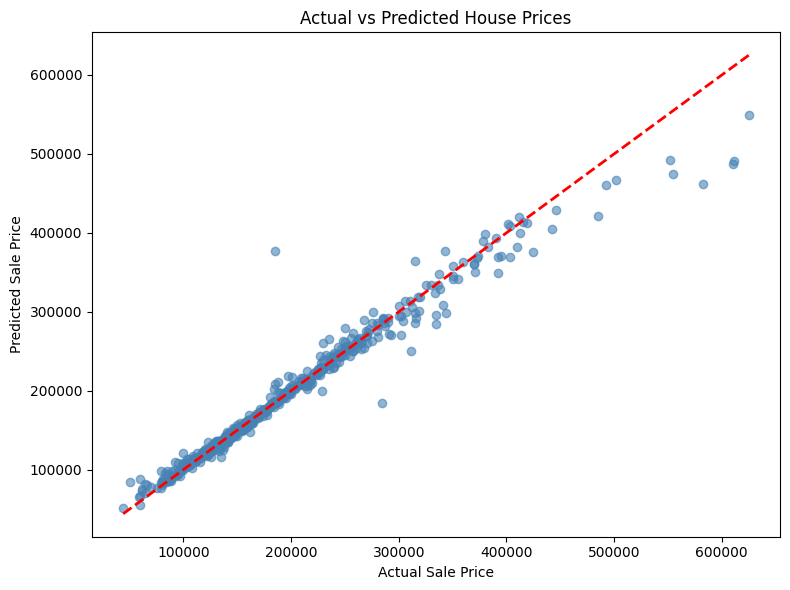

,Metric,Value
0,RMSE,16790.767074
1,R2,0.964836


In [4]:
# Train the best-performing model on the engineered features and plot the predictions
best_row = results_df.sort_values("rmse").iloc[0]
print(f"Best model: {best_row['model']}")

X_train, X_test, y_train, y_test = train_test_split(
    engineered_features, y, test_size=0.2, random_state=42
)

if "RandomForest" in best_row["model"]:
    best_model = RandomForestRegressor(n_estimators=220, random_state=42, n_jobs=-1)
else:
    best_model = Ridge(alpha=1.0)

best_pipeline = Pipeline(
    steps=[
        ("preprocess", build_preprocessor(X_train)),
        ("model", best_model),
    ]
)
best_pipeline.fit(X_train, y_train)
predictions = best_pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

# Print a compact summary table
summary = pd.DataFrame(
    {
        "Metric": ["RMSE", "R2"],
        "Value": [np.sqrt(mean_squared_error(y_test, predictions)), r2_score(y_test, predictions)],
    }
)
summary

## 4. Explain the best model with SHAP

The next step looks at which input features most strongly influence the best model’s predictions.

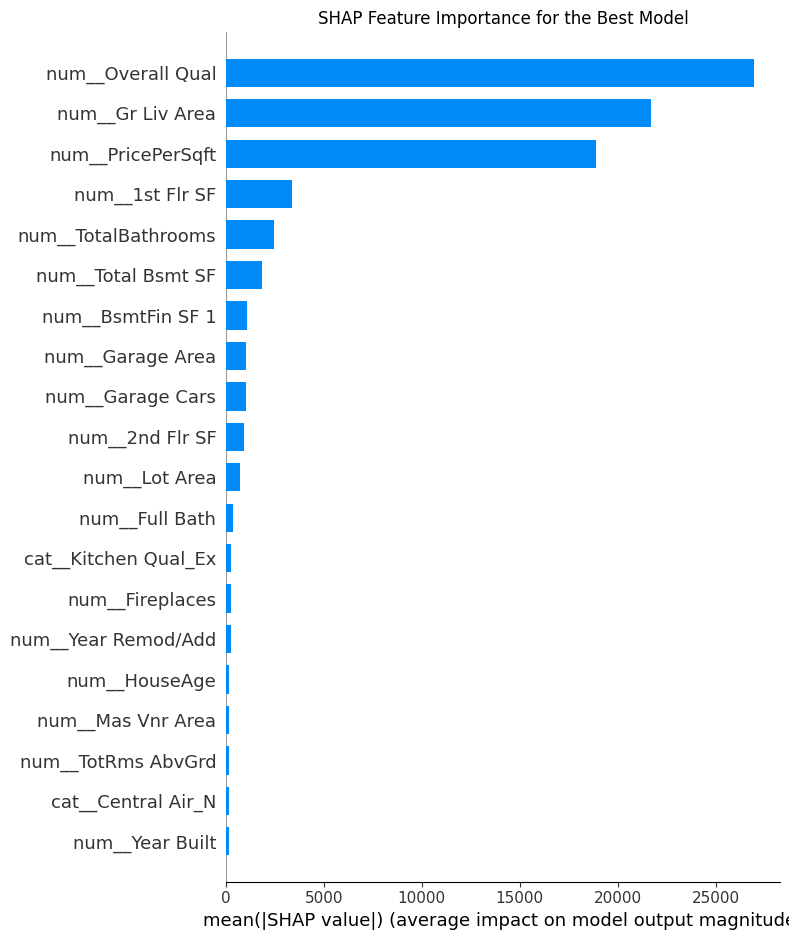

In [5]:
# Build SHAP values for the best model using the transformed training data
X_train_shap = best_pipeline.named_steps["preprocess"].transform(X_train)
feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()

explainer = shap.TreeExplainer(best_pipeline.named_steps["model"])
shap_values = explainer.shap_values(X_train_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X_train_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance for the Best Model")
plt.tight_layout()
plt.show()

In [6]:
# Focus on the numeric columns and measure their correlation with SalePrice
numeric_df = prepared_df.select_dtypes(include=["number"]).copy()

corr_with_price = (
    numeric_df.corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

top_corr = corr_with_price.head(10)
top_corr

Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
PricePerSqft      0.614454
TotalBathrooms    0.580715
Year Built        0.558426
Full Bath         0.545604
Name: SalePrice, dtype: float64

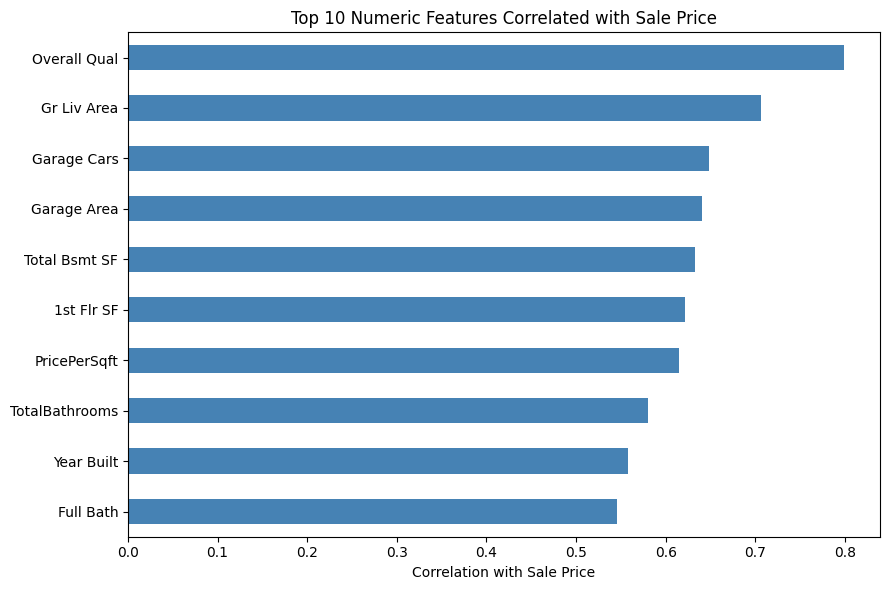

,Average Sale Price,Listings
Neighborhood,,
NoRidge,330319.126761,71
StoneBr,324229.196078,51
NridgHt,322018.265060,166
GrnHill,280000.000000,2
Veenker,248314.583333,24
Timber,246599.541667,72
Somerst,229707.324176,182
ClearCr,208662.090909,44
Crawfor,207550.834951,103


In [7]:
# Plot the strongest numeric relationships
plt.figure(figsize=(9, 6))
top_corr.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 10 Numeric Features Correlated with Sale Price")
plt.xlabel("Correlation with Sale Price")
plt.tight_layout()
plt.show()

# Neighborhood premium summary
neighborhood_summary = (
    prepared_df.groupby("Neighborhood")["SalePrice"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .head(10)
)

neighborhood_summary.rename(columns={"mean": "Average Sale Price", "count": "Listings"})

## 5. Conclusion

The dataset shows that a few structural quality variables, especially those tied to overall home quality and size, are much more strongly related to sale price than many other numeric attributes. Neighborhood also matters, suggesting that location is also important signal in the housing market.